EXPONENTE = 3

  factor    spread    consol   ganador
    0.00     2.040     1.840   CONSOLIDAR
    0.10     2.057     1.920   CONSOLIDAR
    0.20     2.075     2.000   CONSOLIDAR
    0.30     2.092     2.080   CONSOLIDAR
    0.40     2.110     2.160   SPREAD
    0.50     2.127     2.240   SPREAD
    0.60     2.145     2.321   SPREAD
    0.70     2.162     2.401   SPREAD
    0.80     2.180     2.481   SPREAD
    0.90     2.197     2.561   SPREAD
    1.00     2.215     2.641   SPREAD

Umbral (cruce): factor_hotspot = 0.32
  por debajo -> gana CONSOLIDAR
  por encima -> gana SPREAD


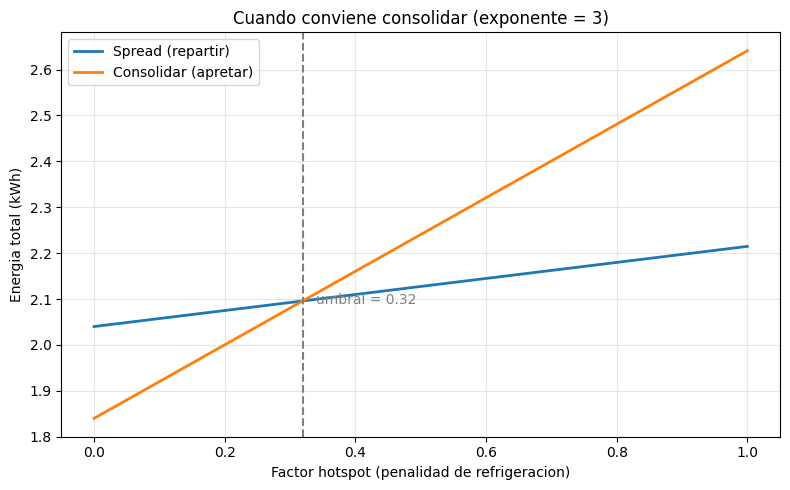

In [12]:
"""
Barrido del factor hotspot - v2
Cambio: el costo de refrigeracion escala con el CUBO de la carga,
no con el cuadrado (leyes de afinidad de ventiladores).
"""
import matplotlib.pyplot as plt

# ---------- PARAMETROS ----------
P_IDLE = 50        # watts de una GPU encendida sin trabajo
P_MAX = 400        # watts a full
EXPONENTE = 3      # <-- toca esto: 2 = modelo viejo, 3 = fisica de ventiladores
HORAS = 1


class GPU:
    def __init__(self, id):
        self.id = id
        self.carga = 0.0
        self.workloads = []

    def encendida(self):
        return self.carga > 0

    def potencia(self):
        if not self.encendida():
            return 0.0
        return P_IDLE + (P_MAX - P_IDLE) * self.carga


class Workload:
    def __init__(self, id, demanda):
        self.id = id
        self.demanda = demanda


# ---------- SCHEDULERS ----------

def spread(gpus, workloads):
    """Reparte las tareas entre todas las GPUs (round-robin)."""
    i = 0
    for w in workloads:
        for _ in range(len(gpus)):
            g = gpus[i % len(gpus)]
            i += 1
            if g.carga + w.demanda <= 1.0:
                g.carga += w.demanda
                g.workloads.append(w.id)
                break
    return gpus


def consolidar(gpus, workloads):
    """Llena una GPU antes de encender la siguiente."""
    for w in workloads:
        for g in gpus:
            if g.carga + w.demanda <= 1.0:
                g.carga += w.demanda
                g.workloads.append(w.id)
                break
    return gpus


# ---------- ENERGIA ----------

def energia_total(gpus, horas, factor_hotspot, exponente=EXPONENTE):
    it = sum(g.potencia() for g in gpus) * horas / 1000
    cool = 0.0
    for g in gpus:
        if g.encendida():
            penalidad = 1 + factor_hotspot * (g.carga ** exponente)
            cool += g.potencia() * penalidad
    cool = cool * horas / 1000
    return it + cool


# ---------- EXPERIMENTO ----------

demandas = [0.5, 0.3, 0.4, 0.2, 0.6, 0.2]
tareas = [Workload(i, d) for i, d in enumerate(demandas)]

# La asignacion no depende del factor: se calcula una sola vez.
gpus_spread = spread([GPU(i) for i in range(5)], tareas)
gpus_consol = consolidar([GPU(i) for i in range(5)], tareas)

factores = [i / 100 for i in range(0, 101)]
e_spread = [energia_total(gpus_spread, HORAS, f) for f in factores]
e_consol = [energia_total(gpus_consol, HORAS, f) for f in factores]

# Buscar el cruce
umbral = None
for i in range(1, len(factores)):
    if (e_consol[i - 1] - e_spread[i - 1]) < 0 <= (e_consol[i] - e_spread[i]):
        umbral = factores[i]
        break

print(f"EXPONENTE = {EXPONENTE}\n")
print(f"{'factor':>8} {'spread':>9} {'consol':>9}   ganador")
for f, a, b in zip(factores, e_spread, e_consol):
    if round(f * 100) % 10 == 0:
        print(f"{f:>8.2f} {a:>9.3f} {b:>9.3f}   "
              f"{'CONSOLIDAR' if b < a else 'SPREAD'}")

if umbral is None:
    print("\nNo hay cruce en el rango 0..1")
else:
    print(f"\nUmbral (cruce): factor_hotspot = {umbral}")
    print("  por debajo -> gana CONSOLIDAR")
    print("  por encima -> gana SPREAD")

# ---------- GRAFICO ----------

plt.figure(figsize=(8, 5))
plt.plot(factores, e_spread, label="Spread (repartir)", linewidth=2)
plt.plot(factores, e_consol, label="Consolidar (apretar)", linewidth=2)
if umbral is not None:
    plt.axvline(umbral, color="gray", linestyle="--")
    plt.text(umbral + 0.02, min(e_spread) + 0.05,
             f"umbral = {umbral:.2f}", color="gray")
plt.xlabel("Factor hotspot (penalidad de refrigeracion)")
plt.ylabel("Energia total (kWh)")
plt.title(f"Cuando conviene consolidar (exponente = {EXPONENTE})")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

exponente 2 → umbral 0.39 / exponente 3 → umbral 0.32 / con tiempo: spread gana 5.5%, consolidar hace 13 arranques vs 8